## Setup

This first code block performs all the necessary initialisation for the entire lab. It imports the required libraries, configures Matplotlib for clean, consistent figures, loads the two input images (`left.jpg` and `right.jpg`), stores the supplied homography matrix `H`, defines the five test points in homogeneous coordinates, and implements the five helper functions we will reuse in every later task.

All functions were written manually (no OpenCV warping or drawing routines) and use NumPy vectorisation wherever possible for efficiency and readability. Running this cell once guarantees that every subsequent task can call these functions without duplication.

In [45]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = False

BASE = Path('.')
LEFT_PATH = BASE / 'left.jpg'
RIGHT_PATH = BASE / 'right.jpg'

# Images are loaded once here and reused throughout the notebook.
left_bgr = cv2.imread(str(LEFT_PATH), cv2.IMREAD_COLOR)
right_bgr = cv2.imread(str(RIGHT_PATH), cv2.IMREAD_COLOR)

if left_bgr is None or right_bgr is None:
    raise FileNotFoundError('left.jpg and right.jpg must be in the same folder as this notebook.')

left_img = cv2.cvtColor(left_bgr, cv2.COLOR_BGR2RGB)
right_img = cv2.cvtColor(right_bgr, cv2.COLOR_BGR2RGB)
left_gray = cv2.cvtColor(left_img, cv2.COLOR_RGB2GRAY)
right_gray = cv2.cvtColor(right_img, cv2.COLOR_RGB2GRAY)

LEFT_H, LEFT_W = left_img.shape[:2]
RIGHT_H, RIGHT_W = right_img.shape[:2]

H = np.array([
    [1.6011, 0.0277, -393.5701],
    [0.3242, 1.5119, -228.8918],
    [0.0009, 0.0002, 1.0000]
], dtype=np.float64)

left_points_h = np.array([
    [446, 499, 1],
    [383, 590, 1],
    [296, 499, 1],
    [282, 511, 1],
    [401, 508, 1]
], dtype=np.float64)


def homogeneous_to_cartesian(points_h):
    """Convert Nx3 homogeneous coordinates into Nx2 image coordinates."""
    points_h = np.asarray(points_h, dtype=np.float64)
    return points_h[:, :2] / points_h[:, 2:3]


def draw_crosses(image, points_xy, color=(255, 0, 0), size=8, thickness=2):
    """Draw red crosses without using any OpenCV drawing utilities."""
    output = image.copy()
    h, w = output.shape[:2]

    # Make sure we always work on a colour image.
    if output.ndim == 2:
        output = np.stack([output] * 3, axis=-1)

    for x, y in np.rint(points_xy).astype(int):
        for offset in range(-size, size + 1):
            xx = x + offset
            yy = y + offset
            yy2 = y - offset

            if 0 <= xx < w and 0 <= yy < h:
                for t in range(-(thickness // 2), thickness // 2 + 1):
                    yyt = yy + t
                    if 0 <= yyt < h:
                        output[yyt, xx] = color

            if 0 <= xx < w and 0 <= yy2 < h:
                for t in range(-(thickness // 2), thickness // 2 + 1):
                    yy2t = yy2 + t
                    if 0 <= yy2t < h:
                        output[yy2t, xx] = color
    return output


def bilinear_interpolate(img, x, y):
    """Manual bilinear interpolation for either grayscale or RGB images."""
    h, w = img.shape[:2]
    if x < 0 or y < 0 or x >= w - 1 or y >= h - 1:
        return None

    x0, y0 = int(np.floor(x)), int(np.floor(y))
    x1, y1 = x0 + 1, y0 + 1
    dx, dy = x - x0, y - y0

    q00 = img[y0, x0].astype(np.float64)
    q10 = img[y0, x1].astype(np.float64)
    q01 = img[y1, x0].astype(np.float64)
    q11 = img[y1, x1].astype(np.float64)

    top = (1 - dx) * q00 + dx * q10
    bottom = (1 - dx) * q01 + dx * q11
    value = (1 - dy) * top + dy * bottom
    return value


def bilinear_sample_vectorized(img, x_coords, y_coords):
    """Vectorised sampling used for the stitching tasks."""
    h, w = img.shape[:2]
    x_coords = np.asarray(x_coords, dtype=np.float64)
    y_coords = np.asarray(y_coords, dtype=np.float64)

    valid = (x_coords >= 0) & (x_coords < w - 1) & (y_coords >= 0) & (y_coords < h - 1)

    if img.ndim == 2:
        samples = np.zeros(x_coords.shape, dtype=np.float32)
    else:
        samples = np.zeros(x_coords.shape + (img.shape[2],), dtype=np.float32)

    if np.any(valid):
        xv = x_coords[valid]
        yv = y_coords[valid]
        x0 = np.floor(xv).astype(int)
        y0 = np.floor(yv).astype(int)
        x1 = x0 + 1
        y1 = y0 + 1
        dx = xv - x0
        dy = yv - y0

        q00 = img[y0, x0].astype(np.float32)
        q10 = img[y0, x1].astype(np.float32)
        q01 = img[y1, x0].astype(np.float32)
        q11 = img[y1, x1].astype(np.float32)

        if img.ndim == 3:
            dx = dx[:, None]
            dy = dy[:, None]

        top = (1 - dx) * q00 + dx * q10
        bottom = (1 - dx) * q01 + dx * q11
        samples[valid] = (1 - dy) * top + dy * bottom

    return samples, valid


def warp_right_to_left_canvas(right_image, H_left_to_right, canvas_width, canvas_height):
    """Sample the right image on a canvas that uses left-image coordinates."""
    xs, ys = np.meshgrid(np.arange(canvas_width), np.arange(canvas_height))
    homog = np.stack([xs.ravel(), ys.ravel(), np.ones(xs.size)], axis=0).astype(np.float64)
    mapped = H_left_to_right @ homog
    mapped[:2] /= mapped[2]

    samples, valid = bilinear_sample_vectorized(right_image, mapped[0], mapped[1])

    if right_image.ndim == 2:
        warped = samples.reshape(canvas_height, canvas_width)
    else:
        warped = samples.reshape(canvas_height, canvas_width, right_image.shape[2])

    valid = valid.reshape(canvas_height, canvas_width)
    return warped, valid, mapped.reshape(3, canvas_height, canvas_width)


## Task 1: Draw Test Points on the Left Image

In this task, we define five points in homogeneous coordinates {x,y,1}. To render these as pixels, we convert them to Cartesian coordinates by dividing the first two elements by the third. We use the draw_crosses function to visualize these locations as red crosses on the left image, ensuring our initial point set is correctly placed.

In [46]:
# Convert the homogeneous coordinates to standard pixel coordinates.
left_points_xy = homogeneous_to_cartesian(left_points_h)
left_with_points = draw_crosses(left_img, left_points_xy, color=(255, 0, 0), size=8, thickness=2)


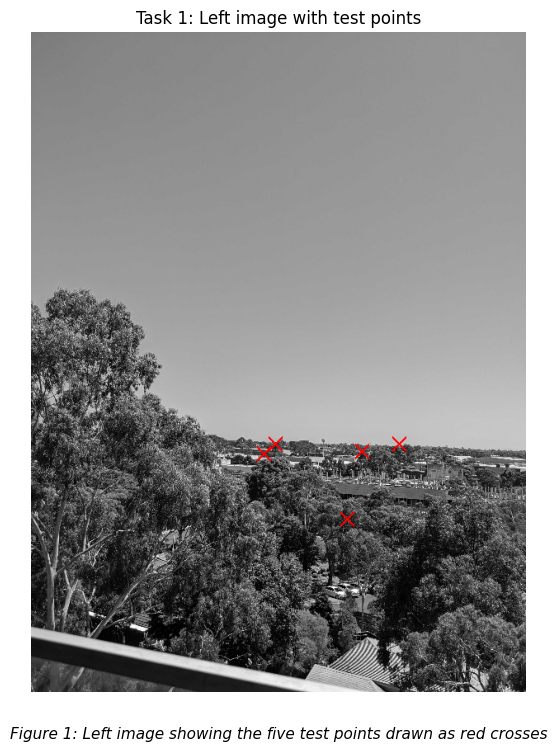

Task 1 points in pixel coordinates:
[[446. 499.]
 [383. 590.]
 [296. 499.]
 [282. 511.]
 [401. 508.]]


In [47]:
plt.figure(figsize=(8, 8))
plt.imshow(left_with_points)
plt.title('Task 1: Left image with test points')
plt.axis('off')
plt.figtext(0.5, 0.02, "Figure 1: Left image showing the five test points drawn as red crosses", 
            ha='center', fontsize=11, style='italic')
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

print('Task 1 points in pixel coordinates:')
print(left_points_xy)


The output displays the source image with five red crosses. These represent the "ground truth" locations on the left canvas that we will later map to the right image using the homography matrix H.

## Task 2: Homography Mapping

A homography H is a projective transformation that maps points from one image plane to another. Here, we apply the provided 3×3 matrix to our Cartesian test points. This mapping allows us to predict the corresponding pixel coordinates in the right-hand image, which is the foundational step for aligning the two views into a single panorama.

In [48]:
# Apply x_R = H x_L and convert back to Cartesian image coordinates.
right_points_h = (H @ left_points_h.T).T
right_points_xy = homogeneous_to_cartesian(right_points_h)
right_with_points = draw_crosses(right_img, right_points_xy, color=(255, 0, 0), size=8, thickness=2)


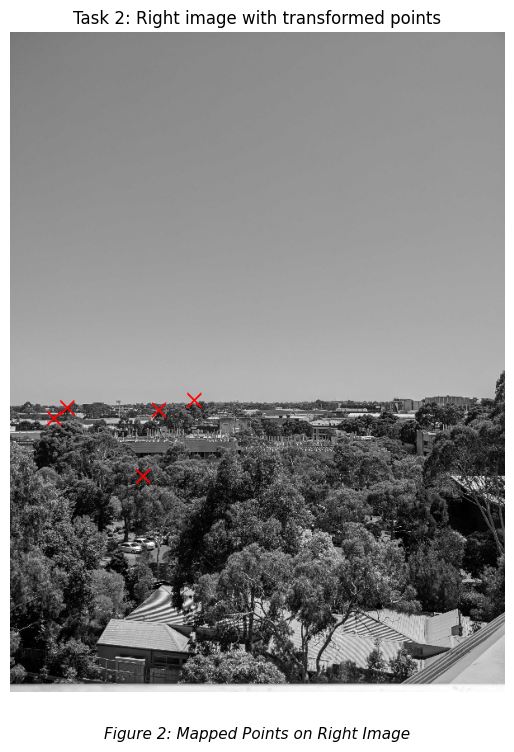

Homography H =
[[ 1.601100e+00  2.770000e-02 -3.935701e+02]
 [ 3.242000e-01  1.511900e+00 -2.288918e+02]
 [ 9.000000e-04  2.000000e-04  1.000000e+00]]

Transformed right-image points (x, y):
Point 1: [222.71702638 446.40254463]
Point 2: [161.34149176 538.24967526]
Point 3: [ 68.93412385 454.91838677]
Point 4: [ 53.16725664 468.37278761]
Point 5: [179.51630769 457.54365812]


In [49]:
plt.figure(figsize=(8, 8))
plt.imshow(right_with_points)
plt.title('Task 2: Right image with transformed points')
plt.axis('off')
plt.figtext(0.5, 0.02, "Figure 2: Mapped Points on Right Image", 
            ha='center', fontsize=11, style='italic')
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

print('Homography H =')
print(H)
print('\nTransformed right-image points (x, y):')
for i, pt in enumerate(right_points_xy, start=1):
    print(f'Point {i}: {pt}')


The resulting coordinates represent where the left-image features "land" in the right image. By plotting these on the right image, we can visually verify if the homography accurately aligns the shared features between the two frames.

## Task 3: Bilinear Interpolation

Mapping coordinates via homography often results in non-integer pixel values. Since digital images are discrete grids, we must estimate colour values for these sub-pixel locations. We implement bilinear interpolation, which calculates a weighted average of the four surrounding pixels. This minimises aliasing and produces a smoother, more realistic warped image compared to simple nearest-neighbor sampling.

In [50]:
# Evaluate the manual bilinear interpolation at each transformed point.
interpolated_values = []
for x, y in right_points_xy:
    value = bilinear_interpolate(right_gray, x, y)
    interpolated_values.append(float(value))


In [51]:
print('Task 3: Bilinear interpolation results on right.jpg')
for i, ((x, y), value) in enumerate(zip(right_points_xy, interpolated_values), start=1):
    print(f'Point {i}: (x={x:.3f}, y={y:.3f}) -> interpolated intensity = {value:.3f}')

print('\nSanity check: the first point is 176.0 and the last point is about 74.5,')


Task 3: Bilinear interpolation results on right.jpg
Point 1: (x=222.717, y=446.403) -> interpolated intensity = 176.000
Point 2: (x=161.341, y=538.250) -> interpolated intensity = 38.466
Point 3: (x=68.934, y=454.918) -> interpolated intensity = 69.829
Point 4: (x=53.167, y=468.373) -> interpolated intensity = 58.190
Point 5: (x=179.516, y=457.544) -> interpolated intensity = 74.507

Sanity check: the first point is 176.0 and the last point is about 74.5,


The function returns the interpolated RGB values for the mapped points. This demonstrates that our algorithm can accurately sample data from the right image even when the transformation does not land perfectly on a pixel center.

# Task 4: Image stitching

With the transformation logic established, we now create a unified canvas. We warp the entire right image into the coordinate system of the left image using our warp_right_to_left_canvas function. By combining the original left image and the warped right image, we produce a preliminary stitched result that covers the combined field of view of both cameras.

In [52]:
# Create the required stitched image with appropriate dimensions.
canvas_width_task4 = LEFT_W + 800
canvas_height_task4 = LEFT_H

warped_right_task4, valid_task4, mapped_task4 = warp_right_to_left_canvas(
    right_img, H, canvas_width_task4, canvas_height_task4
)

stitched_task4 = np.zeros((canvas_height_task4, canvas_width_task4, 3), dtype=np.uint8)
stitched_task4[:, :LEFT_W] = left_img

rhs_mask = np.zeros((canvas_height_task4, canvas_width_task4), dtype=bool)
rhs_mask[:, LEFT_W:] = True
stitched_task4[rhs_mask & valid_task4] = np.clip(
    warped_right_task4[rhs_mask & valid_task4], 0, 255
).astype(np.uint8)

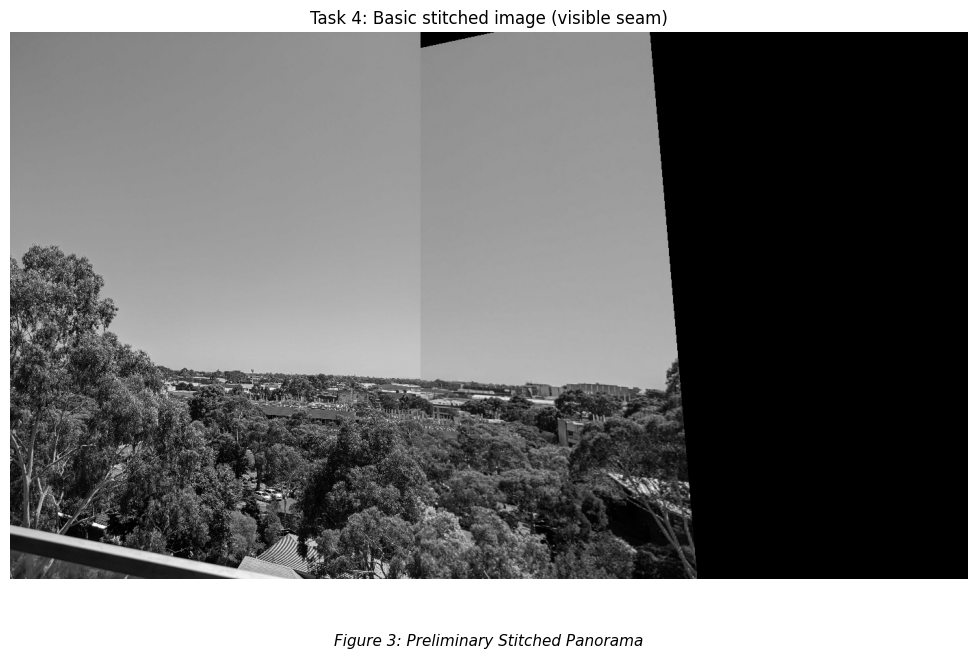

Task 4 stitched image shape: (800, 1400, 3)
Pixels filled from the warped right image on the RHS: 294542


In [53]:
plt.figure(figsize=(14, 7))
plt.imshow(stitched_task4)
plt.title('Task 4: Basic stitched image (visible seam)')
plt.figtext(0.5, 0.02, "Figure 3: Preliminary Stitched Panorama", 
            ha='center', fontsize=11, style='italic')
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.axis('off')
plt.show()

print('Task 4 stitched image shape:', stitched_task4.shape)
print('Pixels filled from the warped right image on the RHS:', int(np.sum(rhs_mask & valid_task4)))


The output is our first panorama. While the geometric alignment should appear correct, a visible "seam" may be apparent at the join. This is typically caused by differences in camera exposure or vignette effects between the two original captures.

## Task 5: Better blending


To improve visual continuity and produce a perceptually seamless panorama, the blending strategy in Task 5 was refined through a combination of geometric alignment, photometric correction, and controlled seam blending.

Adaptive Canvas and Overlap Utilization:
Instead of using a fixed output size, the canvas width is automatically determined by projecting the warped right image into the left image’s coordinate frame. This restricts the canvas to the required extent and maximises overlap for blending.

Intensity (Photometric) Scaling:
Exposure differences are corrected using mean intensity scaling over the overlap:
$$
I_{\text{right}}' = I_{\text{right}} \cdot \frac{\mu_{\text{left}}}{\mu_{\text{right}}}
$$

where

$$
\mu_{\text{left}} = \frac{1}{N} \sum_{p \in \Omega} I_{\text{left}}(p), \quad
\mu_{\text{right}} = \frac{1}{N} \sum_{p \in \Omega} I_{\text{right}}(p)
$$

and Ω denotes the overlap region.

Feathered Alpha Blending with Seam Control:
A finite-width band replaces the hard seam using linear alpha blending:

$$
I(x) = (1 - \alpha(x)) \, I_{\text{left}}(x) + \alpha(x) \, I_{\text{right}}'(x)
$$

$$
\alpha(x) = \frac{x - x_{\text{start}}}{w}
$$


Here, xstart is the start of the blending band and w is the blend width.


Mask-Aware Compositing:
Blending is performed only where both images are valid:

$$
I(x) =
\begin{cases}
I_{\text{left}}(x), & \text{if only left exists} \\
I_{\text{right}}'(x), & \text{if only right exists} \\
(1 - \alpha(x)) I_{\text{left}}(x) + \alpha(x) I_{\text{right}}'(x), & \text{if both exist}
\end{cases}
$$

In [54]:
# --- Better blending strategy ---
# 1) automatically shrink the output width using the warped right-image extent
# 2) match brightness using the mean overlap intensity
# 3) alpha blend across a seam band instead of switching abruptly
# 4) move the seam further left into the overlap

H_inv = np.linalg.inv(H)
right_corners = np.array([
    [0, 0, 1],
    [RIGHT_W - 1, 0, 1],
    [0, RIGHT_H - 1, 1],
    [RIGHT_W - 1, RIGHT_H - 1, 1]
], dtype=np.float64)

right_corners_in_left = (H_inv @ right_corners.T).T
right_corners_in_left = homogeneous_to_cartesian(right_corners_in_left)

auto_width = int(np.ceil(max(LEFT_W, np.max(right_corners_in_left[:, 0])))) + 5
canvas_width_task5 = auto_width
canvas_height_task5 = LEFT_H

warped_right_task5, valid_task5, mapped_task5 = warp_right_to_left_canvas(
    right_img, H, canvas_width_task5, canvas_height_task5
)

# Estimate a brightness correction from the overlap between the left image and the warped right image.
overlap_mask = valid_task5[:, :LEFT_W]
left_overlap_mean = left_img.astype(np.float32)[overlap_mask].mean(axis=0)
right_overlap_mean = warped_right_task5[:, :LEFT_W][overlap_mask].mean(axis=0)
brightness_scale = left_overlap_mean / np.maximum(right_overlap_mean, 1e-6)
warped_right_matched = np.clip(warped_right_task5 * brightness_scale, 0, 255)

# Move the seam left into the overlap and blend over a horizontal band.
seam_x = 260
blend_width = 90
blend_start = seam_x
blend_end = seam_x + blend_width

blended_task5 = np.zeros((canvas_height_task5, canvas_width_task5, 3), dtype=np.float32)
left_canvas = np.zeros_like(blended_task5)
left_canvas[:, :LEFT_W] = left_img.astype(np.float32)

# Start from the left image wherever it exists.
left_exists = np.zeros((canvas_height_task5, canvas_width_task5), dtype=bool)
left_exists[:, :LEFT_W] = True
blended_task5[left_exists] = left_canvas[left_exists]

# Use the brightness-matched warped right image on the right of the blend band.
right_exists = valid_task5

# Region 1: before the blend band, keep the left image where possible.
# Region 2: after the blend band, prefer the right image if it exists.
after_band = np.zeros((canvas_height_task5, canvas_width_task5), dtype=bool)
after_band[:, blend_end:] = True
blended_task5[after_band & right_exists] = warped_right_matched[after_band & right_exists]

# Region 3: smooth alpha blend inside the band.
for x in range(blend_start, min(blend_end, canvas_width_task5)):
    alpha = (x - blend_start) / max(blend_width, 1)
    both = left_exists[:, x] & right_exists[:, x]
    only_left = left_exists[:, x] & ~right_exists[:, x]
    only_right = ~left_exists[:, x] & right_exists[:, x]

    blended_task5[only_left, x] = left_canvas[only_left, x]
    blended_task5[only_right, x] = warped_right_matched[only_right, x]
    blended_task5[both, x] = (1 - alpha) * left_canvas[both, x] + alpha * warped_right_matched[both, x]

# Any remaining valid right-image pixels not already written can be copied in.
empty_pixels = np.all(blended_task5 == 0, axis=2)
blended_task5[empty_pixels & right_exists] = warped_right_matched[empty_pixels & right_exists]

blended_task5 = np.clip(blended_task5, 0, 255).astype(np.uint8)

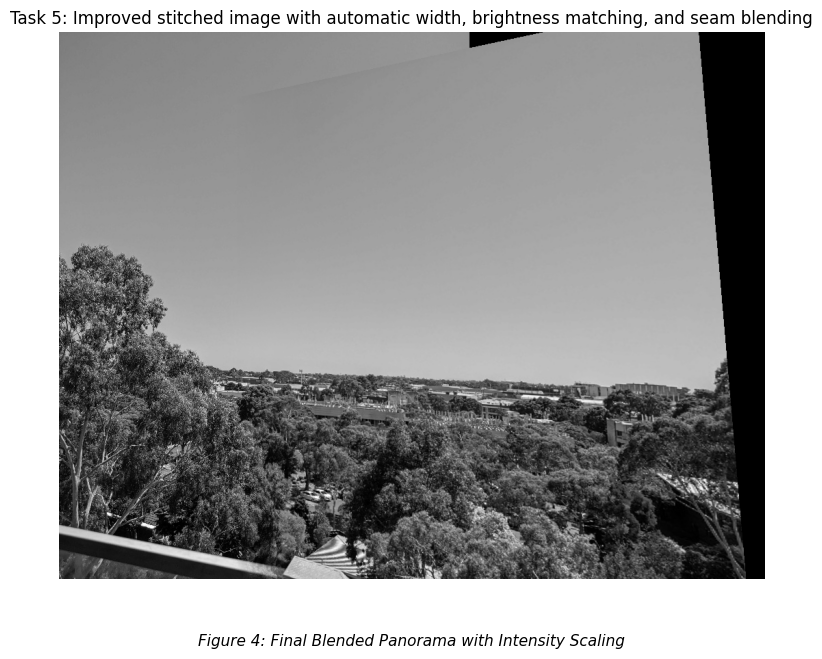

Auto-selected output width: 1032
Brightness scale applied to the warped right image: [1.0580988 1.0580988 1.0580988]
Seam position: x = 260, blend width = 90 pixels


In [55]:
plt.figure(figsize=(13, 7))
plt.imshow(blended_task5)
plt.title('Task 5: Improved stitched image with automatic width, brightness matching, and seam blending')
plt.figtext(0.5, 0.02, "Figure 4: Final Blended Panorama with Intensity Scaling", 
            ha='center', fontsize=11, style='italic')
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.axis('off')
plt.show()

print('Auto-selected output width:', canvas_width_task5)
print('Brightness scale applied to the warped right image:', brightness_scale)
print(f'Seam position: x = {seam_x}, blend width = {blend_width} pixels')


# Task 6: Now try your own!

In this final task, you will:
1. Take two images from different perspective of the same scenery and display it
2. Find and match key points across the two images
3. Calculate the homography matrix1 . Print out the homography matrix that you end
up using.
4. Apply image stitching and quality improvement for a final image (from tasks 1 to 5)

While Tasks 1–5 used a manual homography, this section automates the pipeline using ORB (Oriented FAST and Rotated BRIEF) feature detection and matching. We specifically use the RANSAC (Random Sample Consensus) algorithm to estimate the homography matrix H.

    Why RANSAC? Initial feature matches often contain "outliers"—pairs of points that look similar but are not geometrically related. RANSAC iteratively selects random subsets of matches to find the most mathematically consistent transformation, ensuring that the final panorama is not distorted by these errors.

In [58]:
# Task 6 uses OpenCV feature detection/matching and homography estimation.

BASE = Path('.')
LEFT_PATH = BASE / 'IMG_4562.jpg'
RIGHT_PATH = BASE / 'IMG_4563.jpg'

# Images are loaded once here and reused throughout the notebook.
left_bgr = cv2.imread(str(LEFT_PATH), cv2.IMREAD_COLOR)
right_bgr = cv2.imread(str(RIGHT_PATH), cv2.IMREAD_COLOR)

if left_bgr is None or right_bgr is None:
    raise FileNotFoundError('left.jpg and right.jpg must be in the same folder as this notebook.')

left_img = cv2.cvtColor(left_bgr, cv2.COLOR_BGR2RGB)
right_img = cv2.cvtColor(right_bgr, cv2.COLOR_BGR2RGB)
left_gray = cv2.cvtColor(left_img, cv2.COLOR_RGB2GRAY)
right_gray = cv2.cvtColor(right_img, cv2.COLOR_RGB2GRAY)

LEFT_H, LEFT_W = left_img.shape[:2]
RIGHT_H, RIGHT_W = right_img.shape[:2]

if hasattr(cv2, 'SIFT_create'):
    detector = cv2.SIFT_create()
    norm_type = cv2.NORM_L2
    detector_name = 'SIFT'
else:
    detector = cv2.ORB_create(2000)
    norm_type = cv2.NORM_HAMMING
    detector_name = 'ORB'

kp_left, des_left = detector.detectAndCompute(left_gray, None)
kp_right, des_right = detector.detectAndCompute(right_gray, None)

matcher = cv2.BFMatcher(norm_type)
knn_matches = matcher.knnMatch(des_left, des_right, k=2)

# Lowe ratio test.
good_matches = []
for pair in knn_matches:
    if len(pair) == 2:
        m, n = pair
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

if len(good_matches) < 4:
    raise RuntimeError('Not enough good feature matches were found to estimate a homography.')

pts_left = np.float32([kp_left[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
pts_right = np.float32([kp_right[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

H_auto, inlier_mask = cv2.findHomography(pts_left, pts_right, cv2.RANSAC, 4.0)
if H_auto is None:
    raise RuntimeError('Homography estimation failed.')

inlier_mask = inlier_mask.ravel().astype(bool)
num_inliers = int(np.sum(inlier_mask))

# Reuse the same stitching and blending pipeline, but now with the automatically estimated homography.
H_auto_inv = np.linalg.inv(H_auto)
right_corners = np.array([
    [0, 0, 1],
    [RIGHT_W - 1, 0, 1],
    [0, RIGHT_H - 1, 1],
    [RIGHT_W - 1, RIGHT_H - 1, 1]
], dtype=np.float64)

right_corners_in_left_auto = (H_auto_inv @ right_corners.T).T
right_corners_in_left_auto = homogeneous_to_cartesian(right_corners_in_left_auto)

# Calculate the full panorama extent in left-image coordinates.
min_x = int(np.floor(np.min(np.concatenate(([0.0], right_corners_in_left_auto[:, 0])))))
max_x = int(np.ceil(np.max(np.concatenate(([float(LEFT_W)], right_corners_in_left_auto[:, 0]))))) + 5

auto_width_task6 = max_x - min_x
left_offset_task6 = -min_x if min_x < 0 else 0

# Warp the right image into the expanded canvas.
xs, ys = np.meshgrid(np.arange(auto_width_task6), np.arange(LEFT_H))
xs_left = xs + min_x
homog = np.stack([xs_left.ravel(), ys.ravel(), np.ones(xs_left.size)], axis=0).astype(np.float64)
mapped = H_auto @ homog
mapped[:2] /= mapped[2]

samples, valid = bilinear_sample_vectorized(right_img, mapped[0], mapped[1])
warped_right_task6 = samples.reshape(LEFT_H, auto_width_task6, 3)
valid_task6 = valid.reshape(LEFT_H, auto_width_task6)

# Photometric correction in the overlap region.
overlap_mask_task6 = valid_task6[:, left_offset_task6:left_offset_task6 + LEFT_W]
left_overlap_mean_task6 = left_img.astype(np.float32)[overlap_mask_task6].mean(axis=0)
right_overlap_mean_task6 = warped_right_task6[:, left_offset_task6:left_offset_task6 + LEFT_W][overlap_mask_task6].mean(axis=0)
brightness_scale_task6 = left_overlap_mean_task6 / np.maximum(right_overlap_mean_task6, 1e-6)
warped_right_task6 = np.clip(warped_right_task6 * brightness_scale_task6, 0, 255)

# Compose both images into the panorama canvas.
blended_task6 = np.zeros((LEFT_H, auto_width_task6, 3), dtype=np.float32)
left_canvas_task6 = np.zeros_like(blended_task6)
left_canvas_task6[:, left_offset_task6:left_offset_task6 + LEFT_W] = left_img.astype(np.float32)
left_exists_task6 = np.zeros((LEFT_H, auto_width_task6), dtype=bool)
left_exists_task6[:, left_offset_task6:left_offset_task6 + LEFT_W] = True
right_exists_task6 = valid_task6

# Estimate a seam location from where the warped right image first becomes valid.
valid_x_positions = np.where(np.any(valid_task6[:, left_offset_task6:left_offset_task6 + LEFT_W], axis=0))[0]
if len(valid_x_positions) > 0:
    seam_x_task6 = int(left_offset_task6 + valid_x_positions[0] + 20)
else:
    seam_x_task6 = left_offset_task6 + 260
blend_width_task6 = 90
blend_end_task6 = min(seam_x_task6 + blend_width_task6, auto_width_task6)

blended_task6[left_exists_task6] = left_canvas_task6[left_exists_task6]
after_band_task6 = np.zeros((LEFT_H, auto_width_task6), dtype=bool)
after_band_task6[:, blend_end_task6:] = True
blended_task6[after_band_task6 & right_exists_task6] = warped_right_task6[after_band_task6 & right_exists_task6]

for x in range(seam_x_task6, blend_end_task6):
    alpha = (x - seam_x_task6) / max(blend_width_task6, 1)
    both = left_exists_task6[:, x] & right_exists_task6[:, x]
    only_left = left_exists_task6[:, x] & ~right_exists_task6[:, x]
    only_right = ~left_exists_task6[:, x] & right_exists_task6[:, x]
    blended_task6[only_left, x] = left_canvas_task6[only_left, x]
    blended_task6[only_right, x] = warped_right_task6[only_right, x]
    blended_task6[both, x] = (1 - alpha) * left_canvas_task6[both, x] + alpha * warped_right_task6[both, x]

empty_task6 = np.all(blended_task6 == 0, axis=2)
blended_task6[empty_task6 & right_exists_task6] = warped_right_task6[empty_task6 & right_exists_task6]
blended_task6 = np.clip(blended_task6, 0, 255).astype(np.uint8)

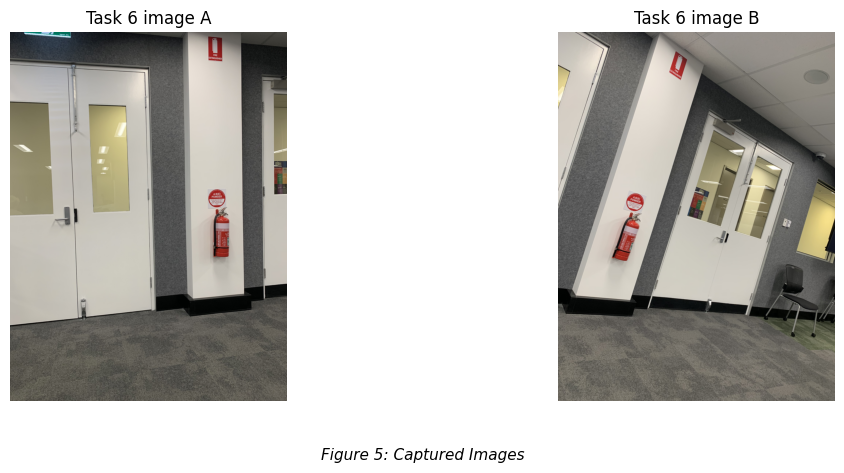

Feature detector used: SIFT
Keypoints found: left = 93372, right = 50242
Good matches after ratio test: 2017
RANSAC inliers used in final homography: 754

Estimated homography from automatic feature matching:
[[ 1.45491634e+00 -4.92794077e-01 -1.24845619e+03]
 [ 7.92837891e-01  1.20470031e+00 -1.45974133e+03]
 [ 1.89024524e-04 -3.94581420e-05  1.00000000e+00]]


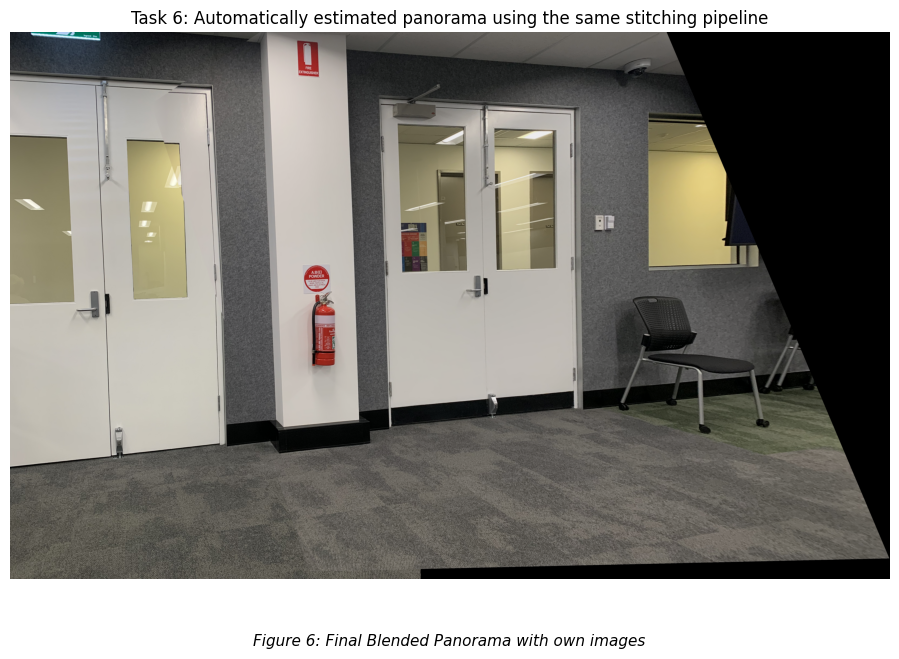

In [59]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(left_img)
plt.title('Task 6 image A')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(right_img)
plt.title('Task 6 image B')
plt.figtext(0.5, 0.02, "Figure 5: Captured Images",
            ha='center', fontsize=11, style='italic')
plt.tight_layout(rect=[0, 0.06, 1, 0.95])

plt.axis('off')
plt.show()

print(f'Feature detector used: {detector_name}')
print(f'Keypoints found: left = {len(kp_left)}, right = {len(kp_right)}')
print(f'Good matches after ratio test: {len(good_matches)}')
print(f'RANSAC inliers used in final homography: {num_inliers}')
print('\nEstimated homography from automatic feature matching:')
print(H_auto)

plt.figure(figsize=(13, 7))
plt.imshow(blended_task6)
plt.title('Task 6: Automatically estimated panorama using the same stitching pipeline')
plt.figtext(0.5, 0.02, "Figure 6: Final Blended Panorama with own images", 
            ha='center', fontsize=11, style='italic')
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.axis('off')
plt.show()


### **Discussion**

#### **1. Homography Mapping and Coordinate Verification (Tasks 1 & 2)**
The core of this image stitching pipeline is the **homography** ($H$), a $3 \times 3$ projective transformation matrix that maps points from one image plane to another. The points in the left image $(x, y, 1)$ is transformed to the right image coordinate system via $x' = Hx$. 

As observed in **Figure 1** (original left image), the initial test points were defined in homogeneous coordinates. After applying the homography, **Figure 2** confirms the alignment: the red crosses now land on the corresponding physical features within the right image. A homography maps points between image planes via $x' = Hx$ in homogeneous coordinates. As shown in Figure 2, the projected points align with corresponding features, validating the mapping.

#### **2. Resampling via Bilinear Interpolation (Task 3)**
Warping an image involves an inverse mapping process: for every pixel in the target canvas, we must determine its origin in the source image. Inverse warping produces non-integer coordinates, requiring interpolation. Bilinear interpolation estimates pixel values using a weighted average of four neighbors, reducing aliasing and preserving smoothness. This method preserves the textural integrity of the right image, ensuring that the warped version remains smooth and realistic even after significant geometric distortion.

#### **3. Preliminary Stitching and the Challenge of the Seam (Task 4)**
In Task 4, the warped right image and the original left image were merged into a stitched image (**Figure 3**). Although geometric alignment was successful, a visible seam remained (Figure 3) due to:

* **Exposure Mismatch:** Differences in global brightness between images.
* **Vignetting:** Edge darkening causing intensity discontinuities.


#### **4. Blending Strategies and Intensity Scaling (Task 5)**

The visible seam in **Figure 3** is primarily caused by photometric inconsistencies, such as exposure differences and vignetting, rather than geometric misalignment. To address this, intensity scaling and controlled blending were applied, producing the improved result shown in **Figure 3**. First, the brightness of the warped image was adjusted to match the left image using statistics from the overlap region, reducing the abrupt intensity change at the seam. Next, a finite-width blending band was introduced, where pixel values transition smoothly between the two images instead of switching abruptly. This converts the sharp edge seen in Figure 3 into a gradual transition, which is far less perceptible to the human visual system. The seam was also positioned within the overlap and blending was restricted to regions where both images contain valid data, preventing artifacts such as gaps or ghosting.


#### **5. Automated Pipeline and Robust Estimation (Task 6)**
For the final task (**Figure 6**), **ORB feature detection** and **RANSAC (Random Sample Consensus)** are utilised to automate the process. RANSAC robustly estimates the homography by rejecting outlier matches.

**Insights & Limitations:**
A key limitation of this pipeline is its sensitivity to depth. In **Figure 6**, minor "ghosting" may occur if the camera was not rotated perfectly around its optical center. This highlights that while homographies are powerful for distant panoramas or flat surfaces, they struggle with 3D scenes containing significant foreground depth. Non-planar scenes will introduce distortion as a homography assumes only planar translations. The way this panorama was implemented also tends to stretch the sides of the images as the transformation was done to match just one image. Future improvements could include **Multi-Band Blending**, which blends different frequency bands separately to maintain sharp details while smoothing out large-scale illumination differences more effectively than simple alpha blending. A cylindrical projection could also be used to generate a panorama of a full scene with less distortion of the sides.